# 🌳 Árbol de Decisión CART — Clasificación Binaria de Aprobación Académica

Construcción, entrenamiento y evaluación de un modelo de **Árbol de Decisión CART** para predecir
si un estudiante **aprueba la asignatura** (`aprobado = 1` si `grade >= 3.0`).

| | |
|---|---|
| **Variable objetivo (Y)** | `aprobado` (1 = grade ≥ 3.0, 0 = grade < 3.0) |
| **Variables predictoras (X)** | `hours`, `sleep`, `attendance`, `screen`, `institucion` (codificada), `mes`, `dia_semana` |
| **Modelo** | `DecisionTreeClassifier` — criterio Gini (CART, scikit-learn) |
| **Estrategia de validación** | Tres splits: 80/20 · 60/40 · 70/30 + búsqueda de `max_depth` óptimo |

> **Pipeline ETL Educación** — datos sintéticos de 2 000 estudiantes en 5 instituciones colombianas almacenados en PostgreSQL.
> A diferencia de la Regresión Logística, el árbol CART **no requiere escalado** de variables y
> mide la importancia de cada predictor mediante la **reducción de impureza Gini**.


## I. Configuración Inicial — Importaciones y Estilo Visual

In [1]:
# ── CELDA 1: Importaciones y bootstrap del path ──────────────────────────────
import sys, os

# Apuntar al subproyecto `Regresión Lineal/educacion/` para reutilizar
# scripts.database.engine (conexión a la BD educacion_db en PostgreSQL).
EDUCACION_DIR = os.path.abspath(os.path.join('..', '..', 'Regresión Lineal', 'educacion'))
if EDUCACION_DIR not in sys.path:
    sys.path.insert(0, EDUCACION_DIR)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve,
    confusion_matrix, ConfusionMatrixDisplay
)

from sqlalchemy import text
from scripts.database import engine

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

print("✅ Librerías importadas correctamente")
print(f"   pandas   {pd.__version__}")
print(f"   numpy    {np.__version__}")
print(f"   seaborn  {sns.__version__}")
print("\n⚠️  Nota: El árbol CART no requiere StandardScaler — se usa X_raw directamente.")


✅ Librerías importadas correctamente
   pandas   3.0.2
   numpy    2.4.4
   seaborn  0.13.2

⚠️  Nota: El árbol CART no requiere StandardScaler — se usa X_raw directamente.


## II. Extracción de Datos desde PostgreSQL

La consulta SQL genera directamente la variable objetivo binaria `aprobado` usando un `CASE WHEN`
sobre la columna `grade` (umbral colombiano estándar: 3.0).


In [2]:
# ── CELDA 2: Extracción SQL ───────────────────────────────────────────────────
SQL_QUERY = """
SELECT
    i.nombre                              AS institucion,
    r.hours,
    r.sleep,
    r.attendance,
    r.screen,
    r.grade,
    r.fecha_registro,
    CASE
        WHEN r.grade >= 3.0 THEN 1
        ELSE 0
    END                                   AS aprobado
FROM registros_estudiantes r
JOIN instituciones i ON r.institucion_id = i.id
ORDER BY r.fecha_registro;
"""

with engine.connect() as conn:
    df_edu = pd.read_sql(text(SQL_QUERY), conn)

print(f"✅ Datos cargados: {df_edu.shape[0]:,} filas × {df_edu.shape[1]} columnas")
print(f"\nColumnas disponibles:\n{df_edu.columns.tolist()}")
print(f"\nBalance de la variable objetivo:")
bal = df_edu['aprobado'].value_counts()
pct = df_edu['aprobado'].value_counts(normalize=True) * 100
print(f"   Aprobado (1): {bal.get(1, 0):,}  ({pct.get(1, 0):.1f}%)")
print(f"   Reprobado (0): {bal.get(0, 0):,}  ({pct.get(0, 0):.1f}%)")
print(f"\nDistribución por institución:")
print(df_edu['institucion'].value_counts())
df_edu.head()


✅ Datos cargados: 2,000 filas × 8 columnas

Columnas disponibles:
['institucion', 'hours', 'sleep', 'attendance', 'screen', 'grade', 'fecha_registro', 'aprobado']

Balance de la variable objetivo:
   Aprobado (1): 1,016  (50.8%)
   Reprobado (0): 984  (49.2%)

Distribución por institución:
institucion
Universidad del Valle         435
Universidad de Antioquia      431
Universidad Nacional          385
Politécnico Grancolombiano    375
Universidad de los Andes      374
Name: count, dtype: int64


,institucion,hours,sleep,attendance,screen,grade,fecha_registro,aprobado
0,Universidad de Antioquia,4.9,6.8,92,4.7,2.99,2025-04-15 12:51:00,0
1,Universidad del Valle,5.0,8.0,80,5.6,3.10,2025-04-15 17:47:00,1
2,Universidad de los Andes,2.6,7.5,70,6.3,1.48,2025-04-15 18:08:00,0
3,Universidad del Valle,2.4,6.4,73,6.2,2.27,2025-04-15 19:27:00,0
4,Universidad de los Andes,2.6,8.3,71,4.7,2.53,2025-04-16 04:33:00,0


## III. Validación y Exploración del Dataset

In [3]:
# ── CELDA 3: Validación y Exploración ────────────────────────────────────────
print("=" * 55)
print("VALIDACIÓN DEL DATASET")
print("=" * 55)

print("\n📋 Tipos de datos y valores nulos:")
print(df_edu.dtypes.to_frame('dtype').join(
    df_edu.isnull().sum().to_frame('nulos')
))

balance = df_edu['aprobado'].value_counts()
pct     = df_edu['aprobado'].value_counts(normalize=True) * 100
print(f"\n🎯 Balance de la variable objetivo:")
print(f"   Aprobado   (1): {balance.get(1, 0):>5,}  ({pct.get(1, 0):.1f}%)")
print(f"   Reprobado  (0): {balance.get(0, 0):>5,}  ({pct.get(0, 0):.1f}%)")

print(f"\n🏫 Instituciones únicas:")
print(df_edu['institucion'].value_counts().to_string())

print(f"\n📊 Estadísticas de Grade por clase:")
print(df_edu.groupby('aprobado')['grade'].describe().round(2))


VALIDACIÓN DEL DATASET

📋 Tipos de datos y valores nulos:
                         dtype  nulos
institucion                str      0
hours                  float64      0
sleep                  float64      0
attendance               int64      0
screen                 float64      0
grade                  float64      0
fecha_registro  datetime64[us]      0
aprobado                 int64      0

🎯 Balance de la variable objetivo:
   Aprobado   (1): 1,016  (50.8%)
   Reprobado  (0):   984  (49.2%)

🏫 Instituciones únicas:
institucion
Universidad del Valle         435
Universidad de Antioquia      431
Universidad Nacional          385
Politécnico Grancolombiano    375
Universidad de los Andes      374

📊 Estadísticas de Grade por clase:
           count  mean   std  min   25%   50%   75%   max
aprobado                                                 
0          984.0  2.38  0.45  1.0  2.10  2.46  2.75  2.99
1         1016.0  3.60  0.45  3.0  3.26  3.50  3.86  5.00


## IV. Preprocesamiento de Datos

### Pasos aplicados
1. **Extracción de features de fecha** — `mes` y `dia_semana` como predictores adicionales.
2. **Relleno de nulos** — mediana para variables numéricas.
3. **Codificación** — One-Hot Encoding para `institucion` (elimina multicolinealidad con `drop_first=True`).

> **Diferencia clave respecto a la Regresión Logística:** el árbol CART **no requiere escalado** (`StandardScaler`).
> Las divisiones del árbol se basan en umbrales, invariantes al escalado.


In [4]:
# ── CELDA 4: Preprocesamiento ─────────────────────────────────────────────────
df = df_edu.copy()

# 4.1 Features de fecha
df['fecha_registro'] = pd.to_datetime(df['fecha_registro'])
df['mes']        = df['fecha_registro'].dt.month
df['dia_semana'] = df['fecha_registro'].dt.dayofweek  # 0=Lunes … 6=Domingo

# 4.2 Relleno de nulos con mediana en numéricas
num_cols = ['hours', 'sleep', 'attendance', 'screen']
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

# 4.3 One-Hot Encoding para `institucion`
df = pd.get_dummies(df, columns=['institucion'], drop_first=True, dtype=int)

# 4.4 Definir X e y  — SIN escalado (CART no lo requiere)
drop_cols = ['aprobado', 'grade', 'fecha_registro']
X = df.drop(columns=drop_cols)
y = df['aprobado']

print("✅ Preprocesamiento completado")
print(f"   Shape X: {X.shape}")
print(f"   Columnas finales: {X.columns.tolist()}")
print(f"\n   Clases en y → 0: {(y==0).sum():,}  |  1: {(y==1).sum():,}")
print("\n⚠️  No se aplica StandardScaler — los árboles CART son invariantes al escalado.")
print("⚠️  Se excluye 'grade' de X porque define directamente la variable objetivo (data leakage).")


✅ Preprocesamiento completado
   Shape X: (2000, 10)
   Columnas finales: ['hours', 'sleep', 'attendance', 'screen', 'mes', 'dia_semana', 'institucion_Universidad Nacional', 'institucion_Universidad de Antioquia', 'institucion_Universidad de los Andes', 'institucion_Universidad del Valle']

   Clases en y → 0: 984  |  1: 1,016

⚠️  No se aplica StandardScaler — los árboles CART son invariantes al escalado.
⚠️  Se excluye 'grade' de X porque define directamente la variable objetivo (data leakage).


## V. Entrenamiento y Evaluación — Tres Splits

Para cada split:
1. Dividir `X` e `y` con `stratify=y`.
2. Entrenar `DecisionTreeClassifier` (criterio Gini) **solo** con entrenamiento.
3. Predecir probabilidades y clases en test.
4. Calcular las 5 métricas: Accuracy, Precision, Recall, F1-Score, ROC-AUC.


In [5]:
# ── CELDA 5: Función de entrenamiento + evaluación ───────────────────────────
def entrenar_evaluar(X, y, test_size, random_state=42, nombre="Split", max_depth=None):
    """
    Entrena DecisionTreeClassifier con un split train/test y devuelve
    un dict con métricas + datos para curva ROC y matriz de confusión.
    """
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )

    modelo = DecisionTreeClassifier(
        criterion='gini',
        max_depth=max_depth,
        min_samples_split=10,
        min_samples_leaf=5,
        class_weight='balanced',
        random_state=random_state,
    )
    modelo.fit(X_train, y_train)

    y_pred = modelo.predict(X_test)
    y_prob = modelo.predict_proba(X_test)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, y_prob)

    return {
        'nombre'    : nombre,
        'train_size': len(X_train),
        'test_size' : len(X_test),
        'accuracy'  : accuracy_score(y_test, y_pred),
        'precision' : precision_score(y_test, y_pred, zero_division=0),
        'recall'    : recall_score(y_test, y_pred, zero_division=0),
        'f1'        : f1_score(y_test, y_pred, zero_division=0),
        'roc_auc'   : roc_auc_score(y_test, y_prob),
        'fpr'       : fpr,
        'tpr'       : tpr,
        'y_test'    : y_test,
        'y_pred'    : y_pred,
        'modelo'    : modelo,
    }

print("✅ Función `entrenar_evaluar` definida correctamente")
print("   · DecisionTreeClassifier — criterio Gini, class_weight='balanced'")


✅ Función `entrenar_evaluar` definida correctamente
   · DecisionTreeClassifier — criterio Gini, class_weight='balanced'


In [6]:
# ── CELDA 6: Ejecutar los tres splits ────────────────────────────────────────
resultados = [
    entrenar_evaluar(X, y, test_size=0.20, nombre="Split 80/20"),
    entrenar_evaluar(X, y, test_size=0.40, nombre="Split 60/40"),
    entrenar_evaluar(X, y, test_size=0.30, nombre="Split 70/30"),
]

print("=" * 65)
print(f"{'MÉTRICAS COMPARATIVAS — ÁRBOL DE DECISIÓN CART':^65}")
print("=" * 65)
header = f"{'Split':<12} {'N Train':>8} {'N Test':>8} {'Acc':>7} {'Prec':>7} {'Recall':>7} {'F1':>7} {'AUC':>7}"
print(header)
print("-" * 65)
for r in resultados:
    print(
        f"{r['nombre']:<12} {r['train_size']:>8,} {r['test_size']:>8,}"
        f" {r['accuracy']:>7.4f} {r['precision']:>7.4f}"
        f" {r['recall']:>7.4f} {r['f1']:>7.4f} {r['roc_auc']:>7.4f}"
    )
print("=" * 65)


         MÉTRICAS COMPARATIVAS — ÁRBOL DE DECISIÓN CART          
Split         N Train   N Test     Acc    Prec  Recall      F1     AUC
-----------------------------------------------------------------
Split 80/20     1,600      400  0.8250  0.8446  0.8030  0.8232  0.8884
Split 60/40     1,200      800  0.8263  0.8450  0.8054  0.8247  0.8848
Split 70/30     1,400      600  0.8200  0.8432  0.7934  0.8176  0.8894


## VI. Búsqueda de Hiperparámetros — `max_depth` Óptimo

Se itera `max_depth` de 1 a 15 usando el split 80/20 para encontrar dónde el modelo generaliza mejor.


🏆 Mejor max_depth según F1-Score (test): 1
   F1-Score test en depth=1: 0.8551


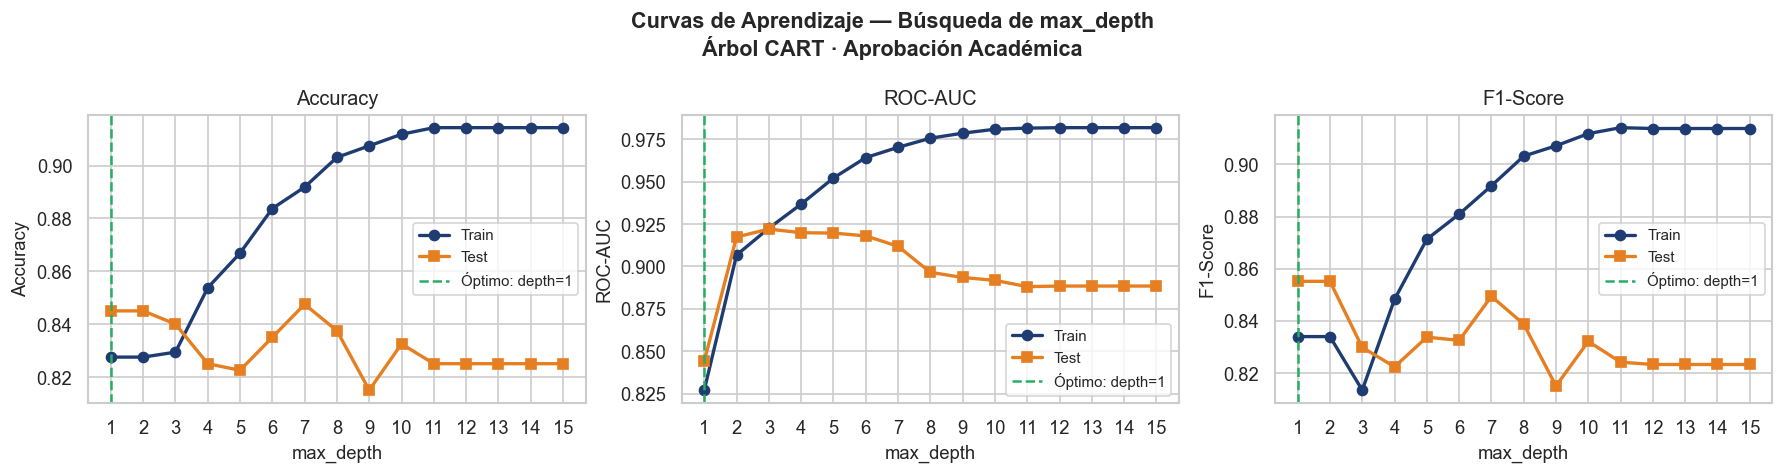

✅ Curvas guardadas en C:\Users\andra\OneDrive\Escritorio\grupo_andrade_tamayo\Regresión Lineal\educacion\data\graficas/max_depth_arbol_edu.png


In [7]:
# ── CELDA 7: Búsqueda de max_depth óptimo ────────────────────────────────────
import os as _os
_GRAFICAS = _os.path.abspath(_os.path.join(EDUCACION_DIR, 'data', 'graficas'))
_os.makedirs(_GRAFICAS, exist_ok=True)

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

profundidades        = range(1, 16)
acc_train, acc_test  = [], []
auc_train, auc_test  = [], []
f1_train,  f1_test   = [], []

for d in profundidades:
    m = DecisionTreeClassifier(
        criterion='gini', max_depth=d,
        min_samples_split=10, min_samples_leaf=5,
        class_weight='balanced', random_state=42
    )
    m.fit(X_tr, y_tr)

    acc_train.append(accuracy_score(y_tr, m.predict(X_tr)))
    auc_train.append(roc_auc_score(y_tr, m.predict_proba(X_tr)[:, 1]))
    f1_train.append(f1_score(y_tr, m.predict(X_tr), zero_division=0))
    acc_test.append(accuracy_score(y_te, m.predict(X_te)))
    auc_test.append(roc_auc_score(y_te, m.predict_proba(X_te)[:, 1]))
    f1_test.append(f1_score(y_te, m.predict(X_te), zero_division=0))

mejor_depth = list(profundidades)[int(np.argmax(f1_test))]
print(f"🏆 Mejor max_depth según F1-Score (test): {mejor_depth}")
print(f"   F1-Score test en depth={mejor_depth}: {max(f1_test):.4f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Curvas de Aprendizaje — Búsqueda de max_depth\nÁrbol CART · Aprobación Académica',
             fontsize=13, fontweight='bold')

metricas_plot = [
    ('Accuracy',  acc_train, acc_test),
    ('ROC-AUC',   auc_train, auc_test),
    ('F1-Score',  f1_train,  f1_test),
]
for ax, (titulo, train_vals, test_vals) in zip(axes, metricas_plot):
    ax.plot(profundidades, train_vals, 'o-', color='#1e3c72', lw=2, label='Train')
    ax.plot(profundidades, test_vals,  's-', color='#e67e22', lw=2, label='Test')
    ax.axvline(x=mejor_depth, color='#27ae60', linestyle='--', lw=1.5, label=f'Óptimo: depth={mejor_depth}')
    ax.set_xlabel('max_depth', fontsize=11)
    ax.set_ylabel(titulo, fontsize=11)
    ax.set_title(titulo, fontsize=12)
    ax.legend(fontsize=9)
    ax.set_xticks(list(profundidades))

plt.tight_layout()
plt.savefig(_os.path.join(_GRAFICAS, 'max_depth_arbol_edu.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Curvas guardadas en {_GRAFICAS}/max_depth_arbol_edu.png")


## VII. Visualizaciones

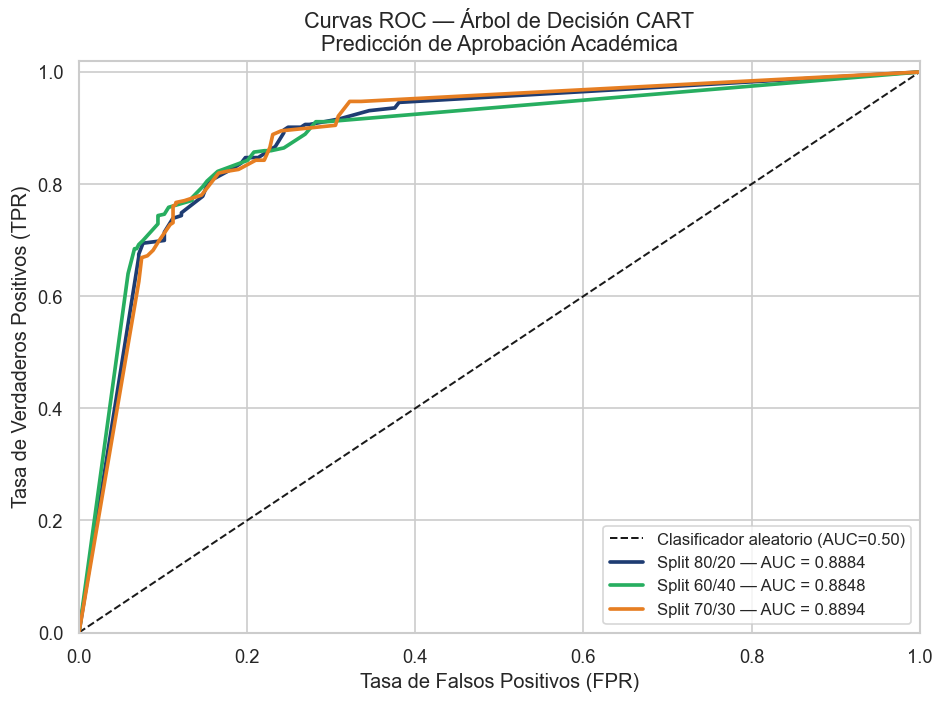

✅ Curvas ROC guardadas en C:\Users\andra\OneDrive\Escritorio\grupo_andrade_tamayo\Regresión Lineal\educacion\data\graficas/roc_arbol_edu.png


In [8]:
# ── CELDA 8: Curvas ROC comparativas ─────────────────────────────────────────
COLORS = ['#1e3c72', '#27ae60', '#e67e22']

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot([0, 1], [0, 1], 'k--', lw=1.2, label='Clasificador aleatorio (AUC=0.50)')

for r, color in zip(resultados, COLORS):
    ax.plot(
        r['fpr'], r['tpr'], color=color, lw=2.2,
        label=f"{r['nombre']} — AUC = {r['roc_auc']:.4f}"
    )

ax.set_xlabel('Tasa de Falsos Positivos (FPR)', fontsize=12)
ax.set_ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=12)
ax.set_title('Curvas ROC — Árbol de Decisión CART\nPredicción de Aprobación Académica', fontsize=13)
ax.legend(loc='lower right', fontsize=10)
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
plt.tight_layout()
plt.savefig(_os.path.join(_GRAFICAS, 'roc_arbol_edu.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Curvas ROC guardadas en {_GRAFICAS}/roc_arbol_edu.png")


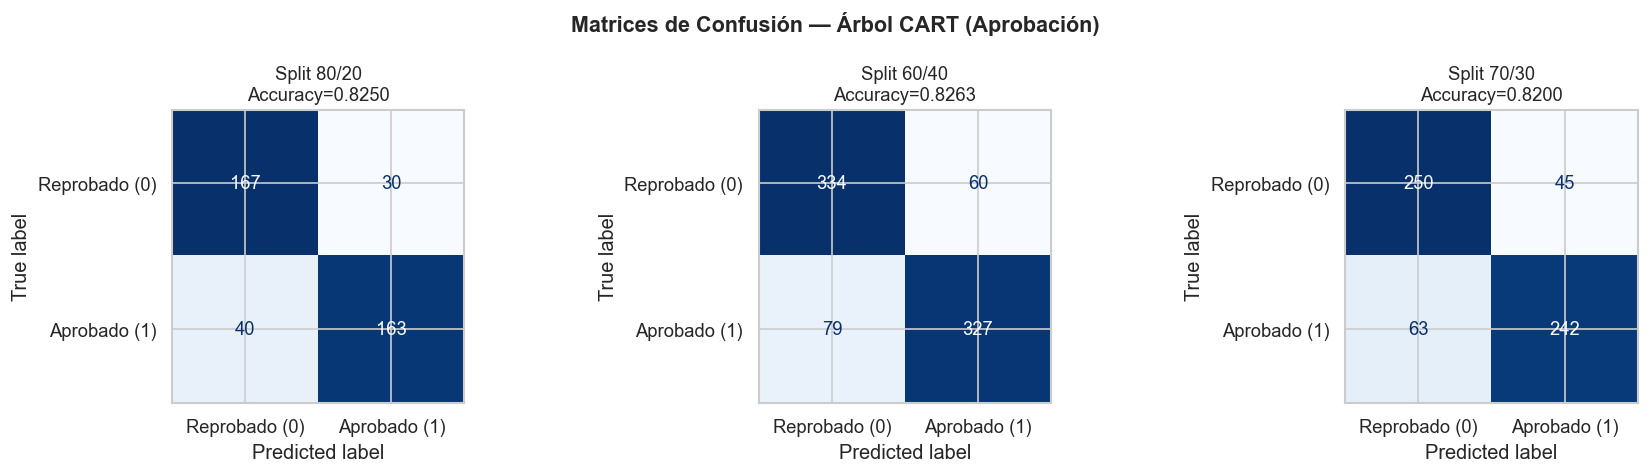

✅ Matrices de confusión guardadas en C:\Users\andra\OneDrive\Escritorio\grupo_andrade_tamayo\Regresión Lineal\educacion\data\graficas/confusion_arbol_edu.png


In [9]:
# ── CELDA 9: Matrices de Confusión (3 splits) ────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Matrices de Confusión — Árbol CART (Aprobación)', fontsize=13, fontweight='bold')

for ax, r, color in zip(axes, resultados, COLORS):
    cm   = confusion_matrix(r['y_test'], r['y_pred'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Reprobado (0)', 'Aprobado (1)'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f"{r['nombre']}\nAccuracy={r['accuracy']:.4f}", fontsize=11)

plt.tight_layout()
plt.savefig(_os.path.join(_GRAFICAS, 'confusion_arbol_edu.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Matrices de confusión guardadas en {_GRAFICAS}/confusion_arbol_edu.png")


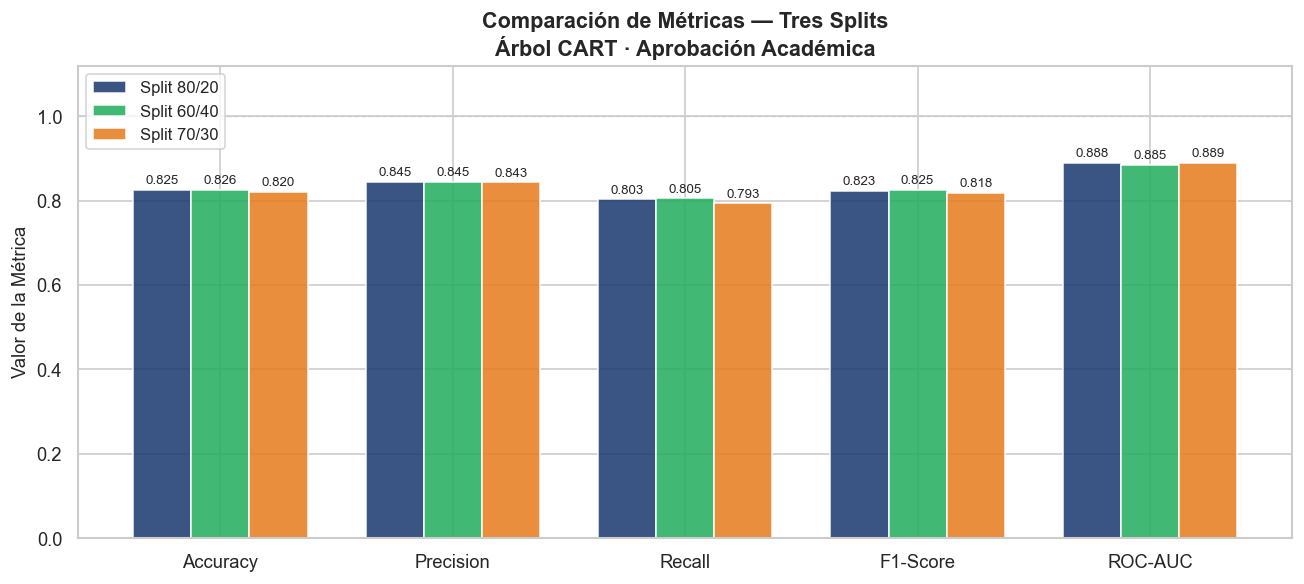

✅ Gráfico de métricas guardado en C:\Users\andra\OneDrive\Escritorio\grupo_andrade_tamayo\Regresión Lineal\educacion\data\graficas/metricas_comparativas_arbol_edu.png


In [10]:
# ── CELDA 10: Gráfico comparativo de métricas ────────────────────────────────
metricas_nombres = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
etiquetas        = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']

x     = np.arange(len(etiquetas))
width = 0.25

fig, ax = plt.subplots(figsize=(11, 5))
for i, (r, color) in enumerate(zip(resultados, COLORS)):
    vals = [r[m] for m in metricas_nombres]
    bars = ax.bar(x + i * width, vals, width, label=r['nombre'], color=color, alpha=0.88)
    ax.bar_label(bars, fmt='%.3f', padding=2, fontsize=8)

ax.set_xticks(x + width)
ax.set_xticklabels(etiquetas, fontsize=11)
ax.set_ylim([0, 1.12])
ax.set_ylabel('Valor de la Métrica', fontsize=11)
ax.set_title('Comparación de Métricas — Tres Splits\nÁrbol CART · Aprobación Académica', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.axhline(y=1.0, color='#ccc', linewidth=0.8, linestyle='--')
plt.tight_layout()
plt.savefig(_os.path.join(_GRAFICAS, 'metricas_comparativas_arbol_edu.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Gráfico de métricas guardado en {_GRAFICAS}/metricas_comparativas_arbol_edu.png")


## VIII. Importancia de Variables — Feature Importance (Gini)

A diferencia de la Regresión Logística (coeficientes lineales), el árbol CART mide la importancia
de cada variable mediante la **reducción promedio de impureza Gini** en todos los nodos donde fue usada.


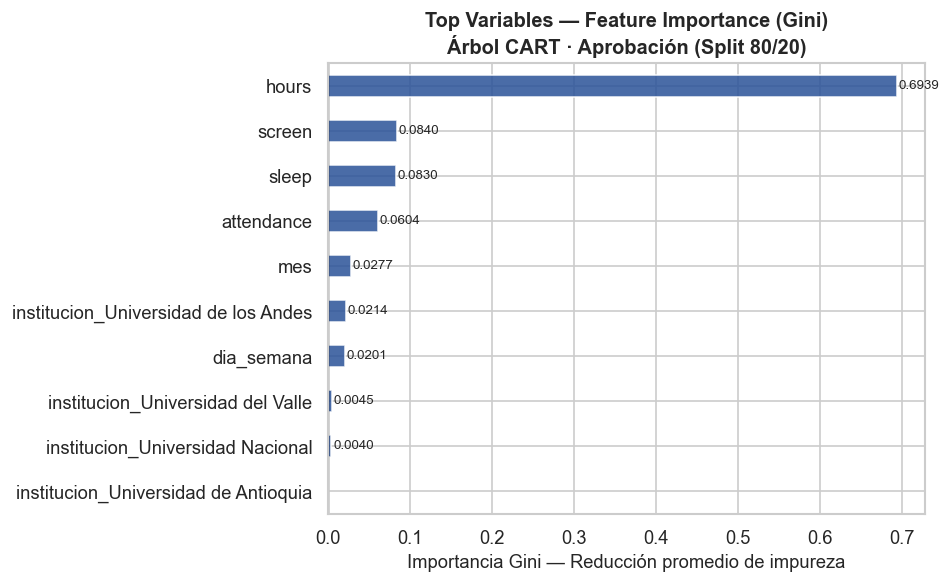

✅ Feature importance guardada en C:\Users\andra\OneDrive\Escritorio\grupo_andrade_tamayo\Regresión Lineal\educacion\data\graficas/feature_importance_arbol_edu.png

📊 Suma de todas las importancias: 1.000000  (debe ser ≈ 1.0)

Top 5 variables más importantes:
hours         0.693940
screen        0.084037
sleep         0.082990
attendance    0.060441
mes           0.027744


In [11]:
# ── CELDA 11: Importancia de variables (Feature Importance Gini) ─────────────
modelo_ref       = resultados[0]['modelo']   # Split 80/20
importancias     = pd.Series(modelo_ref.feature_importances_, index=X.columns)
importancias_ord = importancias.sort_values(ascending=True).tail(12)

fig, ax = plt.subplots(figsize=(8, 5))
importancias_ord.plot(kind='barh', ax=ax, color='#2a5298', alpha=0.85)
ax.set_xlabel('Importancia Gini — Reducción promedio de impureza', fontsize=11)
ax.set_title('Top Variables — Feature Importance (Gini)\nÁrbol CART · Aprobación (Split 80/20)',
             fontsize=12, fontweight='bold')
ax.axvline(x=0, color='black', linewidth=0.8)

for patch in ax.patches:
    width = patch.get_width()
    if width > 0.001:
        ax.text(width + 0.002, patch.get_y() + patch.get_height() / 2,
                f'{width:.4f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig(_os.path.join(_GRAFICAS, 'feature_importance_arbol_edu.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Feature importance guardada en {_GRAFICAS}/feature_importance_arbol_edu.png")
print(f"\n📊 Suma de todas las importancias: {importancias.sum():.6f}  (debe ser ≈ 1.0)")
print(f"\nTop 5 variables más importantes:")
print(importancias.sort_values(ascending=False).head(5).to_string())


## IX. Tabla Final de Métricas

In [12]:
# ── CELDA 12: DataFrame resumen de métricas ──────────────────────────────────
resumen = pd.DataFrame([{
    'Split'          : r['nombre'],
    'N Entrenamiento': r['train_size'],
    'N Prueba'       : r['test_size'],
    'Accuracy'       : round(r['accuracy'],  4),
    'Precision'      : round(r['precision'], 4),
    'Recall'         : round(r['recall'],    4),
    'F1-Score'       : round(r['f1'],        4),
    'ROC-AUC'        : round(r['roc_auc'],   4),
} for r in resultados])

resumen.set_index('Split', inplace=True)

print("=" * 65)
print(f"{'TABLA FINAL DE MÉTRICAS':^65}")
print("=" * 65)
display(resumen.style
    .background_gradient(cmap='Greens', subset=['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'])
    .format('{:.4f}', subset=['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'])
    .set_caption("Árbol de Decisión CART — Clasificación Binaria: Aprobación Académica")
)

print("\n📌 Comparación de modelos (referencia):")
print("   · Regresión Logística — lineal, requiere escalado, interpreta coeficientes.")
print("   · Árbol CART          — no lineal, sin escalado, interpreta importancia Gini.")
print(f"\n   Mejor depth encontrado en sección VI: {mejor_depth}")


                     TABLA FINAL DE MÉTRICAS                     


,N Entrenamiento,N Prueba,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Split,,,,,,,
Split 80/20,1600,400,0.8250,0.8446,0.8030,0.8232,0.8884
Split 60/40,1200,800,0.8263,0.8450,0.8054,0.8247,0.8848
Split 70/30,1400,600,0.8200,0.8432,0.7934,0.8176,0.8894



📌 Comparación de modelos (referencia):
   · Regresión Logística — lineal, requiere escalado, interpreta coeficientes.
   · Árbol CART          — no lineal, sin escalado, interpreta importancia Gini.

   Mejor depth encontrado en sección VI: 1


## X. Conclusiones

### ¿Qué aprendimos con el Árbol CART aplicado al rendimiento académico?

| Aspecto | Observación |
|---------|------------|
| **Sin escalado** | Los árboles CART son invariantes al escalado porque dividen en umbrales; pipeline más simple que la Regresión Logística. |
| **Interpretabilidad** | El árbol puede visualizarse con `plot_tree`. Cada nodo muestra la condición de división, la impureza Gini y la distribución de clases. |
| **Feature Importance** | La importancia Gini mide cuánto reduce cada variable la impureza en promedio (suma = 1.0). |
| **Overfitting** | Los árboles profundos memorizan el entrenamiento. El parámetro `max_depth` controla este trade-off; se seleccionó el óptimo en la sección VI. |
| **`class_weight='balanced'`** | Compensa cualquier desbalance entre aprobados/reprobados ajustando automáticamente los pesos de clase. |
| **Estabilidad** | Si los tres splits arrojan métricas similares, el modelo generaliza bien independientemente de la partición. |

### Comparación con Regresión Logística

| | Regresión Logística | Árbol CART |
|---|---|---|
| **Escalado** | Requerido (StandardScaler) | No requerido |
| **Frontera de decisión** | Lineal | No lineal (por partes) |
| **Importancia de variables** | Coeficientes (log-odds) | Reducción impureza Gini |
| **Riesgo de overfitting** | Bajo (regularización implícita) | Alto si max_depth no se controla |
| **Interpretabilidad** | Ecuación logística | Árbol de reglas if-else |

### Próximos pasos sugeridos
- Reentrenar los tres splits con `max_depth=mejor_depth` para fijar el hiperparámetro óptimo.
- Explorar `RandomForestClassifier` (ensemble) para mayor robustez sobre estudiantes.
- Aplicar validación cruzada (k-fold) para estimación más confiable.
- Considerar features adicionales (asignatura, semestre, antecedente académico) para mejorar la predicción de aprobación.
